In [ ]:
import pandas as pd


dxsum = pd.read_csv("DXSUM_04Oct2025.csv")


important_cols = [
    "PTID",
    "RID",
    "VISCODE",
    "EXAMDATE",
    "DIAGNOSIS",
    "DXNORM",
    "DXMCI",
    "DXAD"
]


if "DXCHANGE" in dxsum.columns:
    important_cols.append("DXCHANGE")


dx_clean = dxsum[important_cols]


print(dx_clean.head())


dx_clean.to_csv("DXSUM_clean.csv", index=False)


         PTID  RID VISCODE    EXAMDATE  DIAGNOSIS  DXNORM  DXMCI  DXAD
0  011_S_0002    2      bl  2005-09-29        1.0     1.0   -4.0  -4.0
1  011_S_0003    3      bl  2005-09-30        3.0    -4.0   -4.0   1.0
2  011_S_0005    5      bl  2005-09-30        1.0     1.0   -4.0  -4.0
3  011_S_0008    8      bl  2005-09-30        1.0     1.0   -4.0  -4.0
4  022_S_0007    7      bl  2005-10-06        3.0    -4.0   -4.0   1.0


In [ ]:
import pandas as pd


mmse = pd.read_csv("MMSE_04Oct2025.csv")


keep_cols = ["PTID", "RID", "VISCODE", "VISDATE", "MMSCORE"]


mmse_clean = mmse[keep_cols]


mmse_clean.head()


mmse_clean.to_csv("MMSE_clean.csv", index=False)
print("MMSE cleaned file saved successfully!")


MMSE cleaned file saved successfully!


In [ ]:
import pandas as pd
import numpy as np

print("\n=== LOADING DATA ===")
dx = pd.read_csv("DXSUM_clean.csv")
mmse = pd.read_csv("MMSE_clean.csv")

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== FIXING VISCODE ISSUES ===")


replace_map = {
    "sc": "bl",     
    "f": "m00",    
    "tau": "bl"     
}

mmse["VISCODE"] = mmse["VISCODE"].replace(replace_map)
dx["VISCODE"] = dx["VISCODE"].replace(replace_map)

print("Unique VISCODEs in DXSUM:", sorted(dx["VISCODE"].unique()))
print("Unique VISCODEs in MMSE:", sorted(mmse["VISCODE"].unique()))

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== MERGING DX + MMSE ===")

merged = dx.merge(
    mmse,
    on=["PTID", "RID", "VISCODE"],
    how="left"     
)

merged.to_csv("DX_MMSE_merged.csv", index=False)
print("Merge complete. File saved: DX_MMSE_merged.csv")

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== MISSING MMSE SCORE REPORT ===")

missing_mmse = merged["MMSCORE"].isna().mean() * 100
print(f"Percentage of missing MMSE: {missing_mmse:.2f}%")

missing_by_viscode = merged.groupby("VISCODE")["MMSCORE"].apply(lambda x: x.isna().mean() * 100)
print("\nMissing MMSE by VISCODE:")
print(missing_by_viscode)

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== DATE MISMATCH CHECK ===")

def to_date(col):
    return pd.to_datetime(col, errors="coerce")

merged["EXAMDATE"] = to_date(merged["EXAMDATE"])
merged["VISDATE"] = to_date(merged["VISDATE"])

merged["DATE_DIFF_DAYS"] = (merged["VISDATE"] - merged["EXAMDATE"]).dt.days


suspicious = merged[merged["DATE_DIFF_DAYS"].abs() > 90]

print(f"Rows with >90 day mismatch: {len(suspicious)}")

suspicious.to_csv("suspicious_date_mismatch.csv", index=False)
print("Saved mismatch rows → suspicious_date_mismatch.csv")

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== DUPLICATE VISIT CHECK ===")

dups = merged[merged.duplicated(["PTID", "RID", "VISCODE"], keep=False)]
print(f"Duplicate visit rows found: {len(dups)}")
dups.to_csv("duplicate_visits.csv", index=False)

# -----------------------------------------------------------

# -----------------------------------------------------------

print("\n=== MERGE SUCCESS SUMMARY ===")

total_visits_dx = len(dx)
total_visits_mmse = len(mmse)
matched_visits = merged["MMSCORE"].notna().sum()

print(f"DX visits total: {total_visits_dx}")
print(f"MMSE visits total: {total_visits_mmse}")
print(f"Matched visits: {matched_visits}")
print(f"Match success rate: {(matched_visits / total_visits_dx) * 100:.2f}%")

# -----------------------------------------------------------

# -----------------------------------------------------------

merged.to_csv("DX_MMSE_merged_clean.csv", index=False)
print("\nFinal cleaned merged file saved: DX_MMSE_merged_clean.csv")

print("\n=== CONSISTENCY CHECK COMPLETE ===")



=== LOADING DATA ===

=== FIXING VISCODE ISSUES ===
Unique VISCODEs in DXSUM: ['4_bl', '4_init', '4_m12', '4_m24', '4_sc', 'bl', 'init', 'm06', 'm12', 'm18', 'm24', 'm36', 'm48', 'm60', 'm72', 'uns1', 'v01', 'v03', 'v05', 'v06', 'v11', 'v21', 'v31', 'v41', 'v51', 'y1', 'y2', 'y3', 'y4', 'y5']
Unique VISCODEs in MMSE: ['4_init', '4_m12', '4_m24', '4_sc', 'bl', 'init', 'm00', 'm06', 'm12', 'm18', 'm24', 'm36', 'm48', 'm60', 'm72', 'v01', 'v05', 'v06', 'v11', 'v21', 'v31', 'v41', 'v51', 'y1', 'y2', 'y3', 'y4', 'y5']

=== MERGING DX + MMSE ===
Merge complete. File saved: DX_MMSE_merged.csv

=== MISSING MMSE SCORE REPORT ===
Percentage of missing MMSE: 10.61%

Missing MMSE by VISCODE:
VISCODE
4_bl      100.000000
4_init     17.365269
4_m12      45.652174
4_m24      40.000000
4_sc        1.955990
bl          0.153198
init        2.457002
m06         0.000000
m12         0.000000
m18         0.000000
m24         0.000000
m36         0.217865
m48         1.176471
m60         0.000000
m72     

In [ ]:
import pandas as pd

df = pd.read_csv("DX_MMSE_merged_clean.csv")

print("=== INITIAL DATA SHAPE ===")
print(df.shape)

print("\n=== REMOVING DUPLICATES ===")
initial_rows = len(df)

df = df.sort_values("EXAMDATE")   
df = df.drop_duplicates(subset=["PTID", "RID", "VISCODE"], keep="first")

removed_duplicates = initial_rows - len(df)

print(f"Duplicates removed: {removed_duplicates}")
print(f"Rows after duplicate removal: {df.shape[0]}")




print("\n=== CHECKING DATE MISMATCH ===")


df["EXAMDATE"] = pd.to_datetime(df["EXAMDATE"], errors="coerce")
df["VISDATE"] = pd.to_datetime(df["VISDATE"], errors="coerce")

# Calculate difference in days
df["date_diff"] = (df["EXAMDATE"] - df["VISDATE"]).dt.days

# Flag mismatches as True/False
df["DATE_MISMATCH_FLAG"] = df["date_diff"].abs() > 90

mismatch_rows = df["DATE_MISMATCH_FLAG"].sum()

print(f"Rows with >90 day mismatch: {mismatch_rows}")


print("\n=== MERGE SUCCESS RECHECK ===")


missing_mmse = df["MMSCORE"].isna().mean() * 100

print(f"Missing MMSE after cleanup: {missing_mmse:.2f}%")


matched = df["MMSCORE"].notna().sum()

print(f"Matched visits: {matched}")
print(f"Total visits: {len(df)}")
print(f"New success rate: {matched/len(df)*100:.2f}%")



df.to_csv("DX_MMSE_ready_for_next_merge.csv", index=False)

print("\n=== CLEANING COMPLETE ===")
print("Final cleaned file saved as: DX_MMSE_ready_for_next_merge.csv")


=== INITIAL DATA SHAPE ===
(15779, 11)

=== REMOVING DUPLICATES ===
Duplicates removed: 697
Rows after duplicate removal: 15082

=== CHECKING DATE MISMATCH ===
Rows with >90 day mismatch: 796

=== MERGE SUCCESS RECHECK ===
Missing MMSE after cleanup: 11.10%
Matched visits: 13408
Total visits: 15082
New success rate: 88.90%

=== CLEANING COMPLETE ===
Final cleaned file saved as: DX_MMSE_ready_for_next_merge.csv


In [ ]:
import pandas as pd
import numpy as np

print("=== LOADING ADAS FILE ===")
adas = pd.read_csv("ADAS_04Oct2025.csv")
print("Initial ADAS shape:", adas.shape)



keep_cols = ["RID", "VISCODE", "VISDATE", "TOTSCORE", "TOTAL13"]
adas = adas[keep_cols]

print("\nColumns after filtering:", adas.columns.tolist())


adas["VISCODE"] = adas["VISCODE"].astype(str).str.lower().str.strip()


adas["VISCODE"] = adas["VISCODE"].replace({"m00": "bl"})

print("\nUnique VISCODEs:", sorted(adas["VISCODE"].unique()))



adas["VISDATE"] = pd.to_datetime(adas["VISDATE"], errors="coerce")

print("\nMissing VISDATE:", adas["VISDATE"].isna().sum())



before = adas.shape[0]
adas = adas.drop_duplicates(subset=["RID", "VISCODE"])
removed = before - adas.shape[0]

print(f"\nDuplicates removed: {removed}")
print("ADAS shape after cleanup:", adas.shape)



print("\n=== MISSING ADAS SCORE REPORT ===")
print("Missing TOTSCORE %:", round(adas["TOTSCORE"].isna().mean()*100, 2))
print("Missing TOTAL13 %:", round(adas["TOTAL13"].isna().mean()*100, 2))

print("\nMissing by VISCODE:")
print(adas.groupby("VISCODE")["TOTSCORE"].apply(lambda x: round(x.isna().mean()*100, 2)))



adas.to_csv("ADAS_ready.csv", index=False)
print("\nCleaned ADAS saved as: ADAS_ready.csv")



print("\n=== LOADING DX+MMSE FILE ===")
dx_mmse = pd.read_csv("DX_MMSE_ready_for_next_merge.csv")


dx_mmse["VISCODE"] = dx_mmse["VISCODE"].astype(str).str.lower().str.strip()

print("DX+MMSE shape:", dx_mmse.shape)



merged = pd.merge(
    dx_mmse,
    adas,
    how="left",
    on=["RID", "VISCODE"]
)

print("\nFinal merged shape:", merged.shape)
print("Missing ADAS after merge:", merged["TOTSCORE"].isna().mean()*100, "%")

merged.to_csv("DX_MMSE_ADAS_merged_clean.csv", index=False)
print("\n=== FINAL MERGED FILE SAVED: DX_MMSE_ADAS_merged_clean.csv ===")


=== LOADING ADAS FILE ===
Initial ADAS shape: (12824, 16)

Columns after filtering: ['RID', 'VISCODE', 'VISDATE', 'TOTSCORE', 'TOTAL13']

Unique VISCODEs: ['4_bl', '4_init', '4_m12', '4_m24', 'bl', 'init', 'm06', 'm12', 'm18', 'm24', 'm36', 'm48', 'm60', 'm72', 'tau', 'uns1', 'v03', 'v05', 'v06', 'v11', 'v21', 'v31', 'v41', 'v51', 'y1', 'y2', 'y3', 'y4', 'y5']

Missing VISDATE: 18

Duplicates removed: 0
ADAS shape after cleanup: (12824, 5)

=== MISSING ADAS SCORE REPORT ===
Missing TOTSCORE %: 1.5
Missing TOTAL13 %: 2.3

Missing by VISCODE:
VISCODE
4_bl       0.86
4_init     7.74
4_m12      3.70
4_m24      0.00
bl         0.61
init       3.19
m06        0.33
m12        0.81
m18        0.30
m24        1.24
m36        1.09
m48        1.18
m60        1.54
m72        0.00
tau        0.00
uns1       0.00
v03        0.25
v05        0.14
v06        0.26
v11        0.53
v21        0.49
v31        0.65
v41        0.89
v51        1.49
y1         3.99
y2         4.38
y3         7.50
y4         3.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("DX_MMSE_ADAS_merged_clean.csv")
print("Initial shape:", df.shape)


cols_to_drop = ["DXNORM", "DXMCI", "DXAD"]   # heavy missing
df.drop(columns=cols_to_drop, inplace=True)
print("After dropping DX columns:", df.shape)


df["MMSCORE"] = df["MMSCORE"].replace(-1, np.nan)
print("MMSE missing %:", df["MMSCORE"].isna().mean() * 100)


for col in ["EXAMDATE", "VISDATE_x", "VISDATE_y"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df = df.sort_values(["PTID", "EXAMDATE"])


df["EXAMDATE"]  = df.groupby("PTID")["EXAMDATE"].transform(lambda x: x.ffill().bfill())
df["VISDATE_x"] = df.groupby("PTID")["VISDATE_x"].transform(lambda x: x.ffill())
df["VISDATE_y"] = df.groupby("PTID")["VISDATE_y"].transform(lambda x: x.ffill())


for col in ["TOTSCORE", "TOTAL13"]:
    df[col] = df.groupby("VISCODE")[col].transform(lambda x: x.fillna(x.median()))


df["TOTSCORE"] = df["TOTSCORE"].fillna(df["TOTSCORE"].median())
df["TOTAL13"]  = df["TOTAL13"].fillna(df["TOTAL13"].median())

print("ADAS missing after imputation:")
print(df[["TOTSCORE", "TOTAL13"]].isna().sum())


df["DATE_DIFF_NEW"] = (df["EXAMDATE"] - df["VISDATE_x"]).dt.days


df_ml = df.copy()


df_ml["VISCODE_CODE"] = df_ml["VISCODE"].astype("category").cat.codes
df_ml["PTID_CODE"]    = df_ml["PTID"].astype("category").cat.codes


cols_to_remove_for_ml = [
    "PTID", "VISCODE",
    "EXAMDATE", "VISDATE_x", "VISDATE_y"
]

df_ml.drop(columns=cols_to_remove_for_ml, inplace=True)
print("ML-ready shape:", df_ml.shape)


df.to_csv("FINAL_CLEAN_FULL.csv", index=False)
df_ml.to_csv("FINAL_ML_READY.csv", index=False)

print("\n=== CLEANING COMPLETE ===")
print("Saved  FINAL_CLEAN_FULL.csv")
print("Saved  FINAL_ML_READY.csv")


Initial shape: (15082, 16)
After dropping DX columns: (15082, 13)
MMSE missing %: 11.172258321177562
ADAS missing after imputation:
TOTSCORE    0
TOTAL13     0
dtype: int64
ML-ready shape: (15082, 11)

=== CLEANING COMPLETE ===
Saved → FINAL_CLEAN_FULL.csv
Saved → FINAL_ML_READY.csv


In [ ]:
import pandas as pd
import numpy as np
import re


def try_rename(df, mapping):
    """Rename columns if present in df according to mapping."""
    existing = {c: mapping[c] for c in mapping if c in df.columns}
    if existing:
        df = df.rename(columns=existing)
    return df

def find_first_match(cols, patterns):
    
    for pat in patterns:
        regex = re.compile(pat, flags=re.IGNORECASE)
        for c in cols:
            if regex.search(c):
                return c
    return None

def parse_apoe_from_text(val):
    
    if pd.isna(val):
        return np.nan
    s = str(val)

    m = re.findall(r'[23|24|34|44|33|22|32|42|\d]', s)
    
    nums = re.findall(r'[234]', s)
    if len(nums) >= 2:
        try:
            a, b = int(nums[0]), int(nums[1])
            return a + b  # sum of alleles (not directly meaningful, but we will compute count of 4s)
        except:
            return np.nan
    return np.nan

def extract_apoe4_count(row, a_col=None, b_col=None, geno_col=None):
    """Robustly compute number of e4 alleles from different column types."""
    
    if a_col and a_col in row.index and b_col and b_col in row.index:
        try:
            a = row[a_col]
            b = row[b_col]
            cnt = 0
            if not pd.isna(a) and int(a) == 4:
                cnt += 1
            if not pd.isna(b) and int(b) == 4:
                cnt += 1
            return cnt
        except:
            pass
    
    if geno_col and geno_col in row.index:
        g = row[geno_col]
        if pd.isna(g):
            return np.nan
        s = str(g)
        
        count4 = len(re.findall(r'4', s))
        
        if '/' in s or re.search(r'\d/\d', s):
            return count4
        
        try:
            val = int(s)
            if val in (0,1,2):
                return val
        except:
            pass
    
    return np.nan


master_path = "FINAL_CLEAN_FULL.csv" 
demo_path   = "All_Subjects_PTDEMOG_04Oct2025.csv"
apoe_path   = "APOERES_11Oct2025.csv"

print("Loading master file:", master_path)
master = pd.read_csv(master_path)
print("Master shape:", master.shape)


print("\nLoading PTDEMOG:", demo_path)
pt = pd.read_csv(demo_path)
print("PTDEMOG shape:", pt.shape)
print("PTDEMOG columns preview:", pt.columns.tolist()[:30])


demo_map_candidates = {

    "PTID": ["ptid", "RID", "Subject ID", "Subject", "PTID"],
    "AGE":  ["age", "AGE", "pt_age", "AGE_AT_BASELINE", "AGE_AT_VISIT"],
    "SEX":  ["sex", "SEX", "PTGENDER", "GENDER"],
    "EDUCATION": ["education", "EDUCATION", "EDUC", "PTEDUCAT", "EDU_YEARS"],
    "RACE": ["race", "RACE"],
    "ETHNICITY": ["ethnicity", "ETHNICITY"],
    "BASELINE_AGE": ["bl_age", "base_age"]
}


pt_renames = {}
cols = pt.columns.tolist()
for canonical, patterns in demo_map_candidates.items():
    found = find_first_match(cols, [r'^' + p + r'$' for p in patterns] + [p for p in patterns])
    if found:
        pt_renames[found] = canonical


if "PTID" not in pt_renames.values():
    if "PTID" in pt.columns:
        pt_renames["PTID"] = "PTID"
    elif "RID" in pt.columns:
        pt_renames["RID"] = "PTID"
    elif "Subject" in pt.columns:
        pt_renames["Subject"] = "PTID"

pt = pt.rename(columns=pt_renames)
print("PTDEMOG renamed mapping:", pt_renames)
if "PTID" not in pt.columns:

    if "RID" in pt.columns:
        pt["PTID"] = pt["RID"].apply(lambda x: f"{int(x):03d}" if isinstance(x, (int,np.integer)) else x)
    else:
        raise ValueError("PTDEMOG file does not have PTID or RID. Cannot merge.")

keep_demo = [c for c in ["PTID", "AGE", "SEX", "EDUCATION", "RACE", "ETHNICITY"] if c in pt.columns]
pt = pt[keep_demo].copy()
print("PTDEMOG keeps:", keep_demo)

if "SEX" in pt.columns:
    pt["SEX"] = pt["SEX"].astype(str).str.strip().str.lower()
    pt["SEX"] = pt["SEX"].replace({
        "m": "male", "male":"male", "1":"male",
        "f": "female","female":"female","2":"female",
        "0":"unknown","n/a":"unknown","nan":"unknown"
    })


if "EDUCATION" in pt.columns:
    pt["EDUCATION"] = pd.to_numeric(pt["EDUCATION"], errors="coerce")

print("PTDEMOG after basic cleaning, sample:")
print(pt.head(5))

print("\nLoading APOE file:", apoe_path)
ap = pd.read_csv(apoe_path)
print("APOE shape:", ap.shape)
print("APOE columns preview:", ap.columns.tolist()[:40])


ap_renames = {}
if "PTID" in ap.columns:
    ap_renames["PTID"] = "PTID"
elif "RID" in ap.columns:

    ap_renames["RID"] = "PTID"

geno_col = find_first_match(ap.columns, [r'geno', r'genotype', r'apoe', r'apoe_gen', r'apoeres', r'apoegeno'])
allele_a = find_first_match(ap.columns, [r'allele1', r'apoe_allele1', r'apoegeno_a', r'allele_a'])
allele_b = find_first_match(ap.columns, [r'allele2', r'allele_b', r'apoegeno_b'])


if geno_col:
    ap_renames[geno_col] = "APOE_GENO"
if allele_a:
    ap_renames[allele_a] = "AL1"
if allele_b:
    ap_renames[allele_b] = "AL2"

ap = ap.rename(columns=ap_renames)
print("APOE renamed mapping:", ap_renames)

if ("APOE_GENO" not in ap.columns) and ("AL1" not in ap.columns and "AL2" not in ap.columns):

    for c in ap.columns:
        sample_vals = ap[c].dropna().astype(str).head(50).tolist()
        if any(re.search(r'\b[23|34|24|33|44|43|42]\b', s) or '/' in s for s in sample_vals):
            ap = ap.rename(columns={c: "APOE_GENO"})
            print("Heuristic: using column", c, "as APOE_GENO")
            break


if "PTID" not in ap.columns:
    if "RID" in ap.columns:
        ap = ap.rename(columns={"RID": "PTID"})
    else:
        raise ValueError("APOE file missing PTID/RID for merging.")


keep_apoe = ["PTID"] + [c for c in ["APOE_GENO", "AL1", "AL2"] if c in ap.columns]
ap = ap[keep_apoe].copy()
print("APOE keeps:", keep_apoe)


def compute_apoe4(row):

    if "AL1" in row.index and "AL2" in row.index:
        try:
            a = row["AL1"]
            b = row["AL2"]
            cnt = 0
            if not pd.isna(a) and str(a).strip() in ("4","e4","ε4","E4"):
                cnt += 1
            if not pd.isna(b) and str(b).strip() in ("4","e4","ε4","E4"):
                cnt += 1
            # if numeric
            try:
                if int(a) == 4:
                    cnt += 0  
            except:
                pass
            return cnt
        except:
            pass
    if "APOE_GENO" in row.index:
        g = row["APOE_GENO"]
        if pd.isna(g):
            return np.nan
        s = str(g)
        
        if '/' in s or re.search(r'\d/\d', s):
            return len(re.findall(r'4', s))
        
        if re.search(r'(?i)e4|ε4|\b4\b', s):
            return len(re.findall(r'4', s))
        
        try:
            val = int(s)
            if val in (0,1,2):
                return val
        except:
            pass
    return np.nan

ap["APOE4_count"] = ap.apply(compute_apoe4, axis=1)

ap["APOE4_carrier"] = ap["APOE4_count"].apply(lambda x: 1 if (not pd.isna(x) and x >= 1) else (0 if not pd.isna(x) and x == 0 else np.nan))

print("APOE counts computed. Sample:")
print(ap.head(6))


print("\nMerging PTDEMOG into master on PTID...")

master["PTID"] = master["PTID"].astype(str)
pt["PTID"] = pt["PTID"].astype(str)
ap["PTID"] = ap["PTID"].astype(str)

merged = master.merge(pt.drop_duplicates(subset=["PTID"]), on="PTID", how="left", validate="m:1")
print("After PTDEMOG merge shape:", merged.shape)


print("\nMerging APOE into merged dataset on PTID...")
merged = merged.merge(ap.drop_duplicates(subset=["PTID"]), on="PTID", how="left", validate="m:1")
print("After APOE merge shape:", merged.shape)

print("\nHandling missing values for demographics and APOE...")

for numcol in ["AGE", "EDUCATION"]:
    if numcol in merged.columns:
        median_val = merged[numcol].median()
        merged[numcol] = merged[numcol].fillna(median_val)
        print(f"Filled {numcol} missing with median {median_val}")

for catcol in ["SEX", "RACE", "ETHNICITY"]:
    if catcol in merged.columns:
        mode_val = merged[catcol].mode(dropna=True)
        if len(mode_val) > 0:
            merged[catcol] = merged[catcol].fillna(mode_val.iloc[0])
            print(f"Filled {catcol} missing with mode '{mode_val.iloc[0]}'")


print("APOE4_count missing %:", merged["APOE4_count"].isna().mean() if "APOE4_count" in merged.columns else "no APOE field")


print("\nCreating derived features...")

if "SEX" in merged.columns:
    merged["SEX_BIN"] = merged["SEX"].map(lambda s: 1 if str(s).lower().startswith("m") else 0)


if "APOE4_carrier" in merged.columns:
    merged["APOE4_carrier"] = merged["APOE4_carrier"].fillna(0).astype(int)
else:

    merged["APOE4_carrier"] = 0
    merged["APOE4_count"] = 0


if "AGE" in merged.columns:
    merged["AGE_BIN"] = pd.cut(merged["AGE"], bins=[0,64,74,84,200], labels=["<65","65-74","75-84","85+"])

print("\nFinal column check:")
print(merged.columns.tolist())

drop_pre_ml = []
for c in ["APOE_GENO", "AL1", "AL2"]:
    if c in merged.columns:
        drop_pre_ml.append(c)

merged.drop(columns=drop_pre_ml, inplace=True, errors="ignore")

out_full = "FINAL_CLEAN_FULL_with_demo_apoe.csv"
merged.to_csv(out_full, index=False)
print("Saved full merged file:", out_full)

print("\nCreating ML-ready dataframe (numeric encoding)...")
ml = merged.copy()

if "SEX_BIN" not in ml.columns and "SEX" in ml.columns:
    ml["SEX_BIN"] = ml["SEX"].map(lambda s: 1 if str(s).lower().startswith("m") else 0)

one_hot_cols = []
if "AGE_BIN" in ml.columns:
    one_hot_cols.append("AGE_BIN")
if "RACE" in ml.columns:
    one_hot_cols.append("RACE")

ml = pd.get_dummies(ml, columns=one_hot_cols, drop_first=True)


text_cols = ml.select_dtypes(include=["object"]).columns.tolist()

for c in ["PTID", "EXAMDATE", "VISDATE_x", "VISDATE_y"]:
    if c in ml.columns:
        text_cols.remove(c) if c in text_cols else None

ml.drop(columns=text_cols, inplace=True, errors="ignore")


ml = ml.loc[:,~ml.columns.duplicated()]

out_ml = "FINAL_ML_READY_with_demo_apoe.csv"
ml.to_csv(out_ml, index=False)
print("Saved ML-ready file:", out_ml)


print("\nMerge summary:")
print("Final full shape:", merged.shape)
print("Final ML shape:", ml.shape)
if "APOE4_carrier" in merged.columns:
    print("APOE4_carrier distribution:")
    print(merged["APOE4_carrier"].value_counts(dropna=False))

print("\nDone.")


Loading master file: FINAL_CLEAN_FULL.csv
Master shape: (15082, 14)

Loading PTDEMOG: All_Subjects_PTDEMOG_04Oct2025.csv
PTDEMOG shape: (6209, 84)
PTDEMOG columns preview: ['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'PTSOURCE', 'PTGENDER', 'PTDOB', 'PTDOBYY', 'PTHAND', 'PTMARRY', 'PTEDUCAT', 'PTWORKHS', 'PTWORK', 'PTNOTRT', 'PTRTYR', 'PTHOME', 'PTTLANG', 'PTPLANG', 'PTADBEG', 'PTCOGBEG', 'PTADDX', 'PTETHCAT', 'PTRACCAT', 'PTIDENT', 'PTORIENT', 'PTORIENTOT', 'PTENGSPK', 'PTNLANG']
PTDEMOG renamed mapping: {'PTID': 'PTID', 'PTENGSPKAGE': 'AGE', 'PTGENDER': 'SEX', 'PTEDUCAT': 'EDUCATION'}
PTDEMOG keeps: ['PTID', 'AGE', 'SEX', 'EDUCATION']
PTDEMOG after basic cleaning, sample:
         PTID  AGE  SEX  EDUCATION
0  011_S_0002  NaN  1.0       16.0
1  022_S_0001  NaN  2.0       18.0
2  011_S_0003  NaN  1.0       18.0
3  022_S_0004  NaN  1.0       10.0
4  011_S_0005  NaN  1.0       16.0

Loading APOE file: APOERES_11Oct2025.csv
APOE shape: (3006, 16)
APOE columns preview: ['PHAS

In [ ]:
import pandas as pd
import numpy as np
import re

master_path = "FINAL_CLEAN_FULL_with_demo_apoe.csv"  
pt_path     = "All_Subjects_PTDEMOG_04Oct2025.csv"    


master = pd.read_csv(master_path, dtype=str)  
pt = pd.read_csv(pt_path, dtype=str)

print("Loaded master:", master.shape)
print("Loaded PTDEMOG:", pt.shape)

candidates = ["PTDOBYY", "PTDOB", "PTBDATE", "DOB", "BIRTHDATE", "BIRTH_YEAR", "PTDOB_YR", "PTDOBYY_"]

found = {}
for col in pt.columns:
    col_low = col.lower()
    for cand in candidates:
        if cand.lower() == col_low:
            found["year_col"] = col
            break

if "year_col" not in found:
    for col in pt.columns:
        if re.search(r'dob|birth|year|ptdob', col, flags=re.I):
            sample = pt[col].dropna().astype(str).head(20).tolist()
            if any(re.match(r'^\d{4}$', s) for s in sample) or any(re.search(r'[/-]', s) for s in sample):
                found["year_col"] = col
                break

if "year_col" not in found:
    raise ValueError("Could not find a DOB / birth-year column automatically in PTDEMOG. Please tell me the correct column name.")

dob_col = found["year_col"]
print("Using PTDEMOG column for birth info:", dob_col)


def extract_birth_year(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    m = re.match(r'^\s*(\d{4})\s*$', s)
    if m:
        return int(m.group(1))

    m = re.search(r'(\d{4})', s)
    if m:
        return int(m.group(1))

    return np.nan

pt["BIRTH_YEAR_EXTRACTED"] = pt[dob_col].apply(extract_birth_year)


if "PTDOBYY" in pt.columns and pt["PTDOBYY"].notna().sum() > 0:
    pt["BIRTH_YEAR_EXTRACTED"] = pt["PTDOBYY"].apply(lambda x: int(x) if pd.notna(x) and re.match(r'^\d{4}$', str(x).strip()) else np.nan).fillna(pt["BIRTH_YEAR_EXTRACTED"])

n_with_year = pt["BIRTH_YEAR_EXTRACTED"].notna().sum()
print(f"PTDEMOG: extracted birth year for {n_with_year} / {len(pt)} subjects")

pt["PTID"] = pt["PTID"].astype(str).str.strip()
master["PTID"] = master["PTID"].astype(str).str.strip()

birth_map = pt.dropna(subset=["BIRTH_YEAR_EXTRACTED"]).drop_duplicates(subset=["PTID"]).set_index("PTID")["BIRTH_YEAR_EXTRACTED"].to_dict()


master["BIRTH_YEAR"] = master["PTID"].map(birth_map).astype(float)


def parse_year_from_date_series(df, cols_priority=["EXAMDATE", "VISDATE_x", "VISDATE_y"]):
   
    year_series = pd.Series(index=df.index, dtype=float)
    for c in cols_priority:
        if c in df.columns:
            ys = pd.to_datetime(df[c], errors="coerce").dt.year

            year_series = year_series.fillna(ys)
    return year_series

master["VISIT_YEAR"] = parse_year_from_date_series(master, ["EXAMDATE", "VISDATE_x", "VISDATE_y"])


master["COMPUTED_AGE"] = master["VISIT_YEAR"] - master["BIRTH_YEAR"]


mask_bad = (master["COMPUTED_AGE"].notna()) & ((master["COMPUTED_AGE"] < 30) | (master["COMPUTED_AGE"] > 120))
print("Number of unrealistic computed ages (will be set to NaN):", mask_bad.sum())
master.loc[mask_bad, "COMPUTED_AGE"] = np.nan


if "AGE" in master.columns:
    
    try:
        master["AGE_OLD_NUM"] = pd.to_numeric(master["AGE"], errors="coerce")
    except:
        master["AGE_OLD_NUM"] = np.nan
    compare = master[["PTID", "VISCODE", "AGE_OLD_NUM", "COMPUTED_AGE"]].copy()
    diff_count = compare[(compare["AGE_OLD_NUM"].notna()) & (compare["COMPUTED_AGE"].notna()) & (compare["AGE_OLD_NUM"] != compare["COMPUTED_AGE"])].shape[0]
    print("Rows where old AGE and computed AGE both present but differ:", diff_count)
    # show some examples
    print(compare[compare["AGE_OLD_NUM"].notna() & compare["COMPUTED_AGE"].notna() & (compare["AGE_OLD_NUM"] != compare["COMPUTED_AGE"])].head(10))


master["AGE_FIXED"] = master["COMPUTED_AGE"].fillna(master.get("AGE_OLD_NUM", np.nan))


median_age = master["AGE_FIXED"].median()
print("Median age (computed) =", median_age)



master["AGE"] = master["AGE_FIXED"]
cols_to_drop = ["BIRTH_YEAR_EXTRACTED", "BIRTH_YEAR", "VISIT_YEAR", "COMPUTED_AGE", "AGE_OLD_NUM", "AGE_FIXED"]
for c in cols_to_drop:
    if c in master.columns:
        master.drop(columns=[c], inplace=True)


out_path = "FINAL_CLEAN_FULL_with_demo_apoe_age_fixed.csv"
master.to_csv(out_path, index=False)
print("Saved updated master with fixed AGE:", out_path)


print("\nSummary:")
print("Total rows:", len(master))
print("Rows with AGE now non-missing:", master["AGE"].notna().sum(), "(", round(master['AGE'].notna().mean()*100,2), "% )")
print("AGE min/median/max:", master["AGE"].min(), master["AGE"].median(), master["AGE"].max())


Loaded master: (15082, 21)
Loaded PTDEMOG: (6209, 84)
Using PTDEMOG column for birth info: PTDOBYY
PTDEMOG: extracted birth year for 6021 / 6209 subjects
Number of unrealistic computed ages (will be set to NaN): 0
Rows where old AGE and computed AGE both present but differ: 15078
         PTID VISCODE  AGE_OLD_NUM  COMPUTED_AGE
0  002_S_0295      bl          8.0          85.0
1  002_S_0295     m06          8.0          85.0
2  002_S_0295     m12          8.0          86.0
3  002_S_0295     m24          8.0          87.0
4  002_S_0295     m36          8.0          88.0
5  002_S_0295     m48          8.0          89.0
6  002_S_0295     v06          8.0          90.0
7  002_S_0295     v11          8.0          91.0
8  002_S_0413      bl          8.0          77.0
9  002_S_0413     m06          8.0          77.0
Median age (computed) = 75.0
Saved updated master with fixed AGE: FINAL_CLEAN_FULL_with_demo_apoe_age_fixed.csv

Summary:
Total rows: 15082
Rows with AGE now non-missing: 15082 ( 1

In [ ]:
import pandas as pd

df["EXAMDATE"] = pd.to_datetime(df["EXAMDATE"], errors="coerce")

demo = pd.read_csv("All_Subjects_PTDEMOG_04Oct2025.csv")


demo["PTDOBYY"] = pd.to_numeric(demo["PTDOBYY"], errors="coerce")

birth_year = demo[["PTID", "PTDOBYY"]].dropna().drop_duplicates()

df["COMPUTED_AGE"] = df["EXAMDATE"].dt.year - df["PTDOBYY"]

df.loc[(df["COMPUTED_AGE"] < 50) | (df["COMPUTED_AGE"] > 120), "COMPUTED_AGE"] = None


df["COMPUTED_AGE"] = df["COMPUTED_AGE"].fillna(df["COMPUTED_AGE"].median())


df["AGE"] = df["COMPUTED_AGE"]


df.drop(columns=["COMPUTED_AGE", "PTDOBYY"], inplace=True)


df.to_csv("FINAL_CLEAN_FULL_with_demo_apoe_age_fixed.csv", index=False)

print("AGE fixed successfully!")
print("AGE stats:", df["AGE"].describe())
print(df[["PTID", "EXAMDATE", "AGE"]].head())


AGE fixed successfully!
AGE stats: count    15168.000000
mean        74.961828
std          7.921838
min         50.000000
25%         70.000000
50%         75.000000
75%         81.000000
max        105.000000
Name: AGE, dtype: float64
         PTID   EXAMDATE   AGE
0  002_S_0295 2006-05-10  85.0
1  002_S_0295 2006-11-08  85.0
2  002_S_0295 2007-05-25  86.0
3  002_S_0295 2008-08-04  87.0
4  002_S_0295 2009-05-26  88.0


----- Dataset Info -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15168 entries, 0 to 15167
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PTID                15168 non-null  object 
 1   RID                 15168 non-null  int64  
 2   VISCODE             15168 non-null  object 
 3   EXAMDATE            15142 non-null  object 
 4   DIAGNOSIS           15127 non-null  float64
 5   VISDATE_x           15160 non-null  object 
 6   MMSCORE             13476 non-null  float64
 7   DATE_DIFF_DAYS      13516 non-null  float64
 8   date_diff           13516 non-null  float64
 9   DATE_MISMATCH_FLAG  15168 non-null  bool   
 10  VISDATE_y           13018 non-null  object 
 11  TOTSCORE            15168 non-null  float64
 12  TOTAL13             15168 non-null  float64
 13  DATE_DIFF_NEW       15134 non-null  float64
 14  AGE                 15168 non-null  float64
 15  SEX                 15168 no

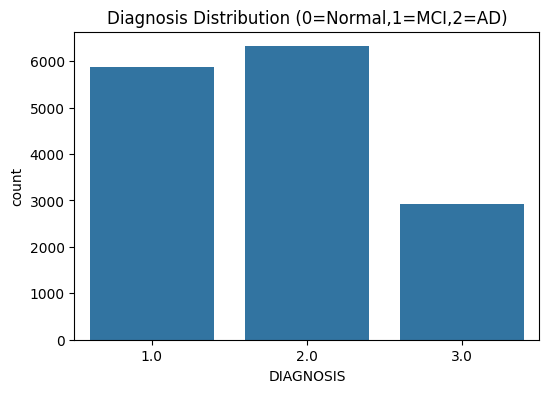

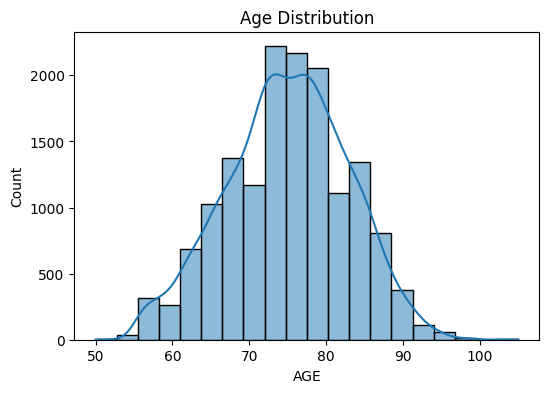

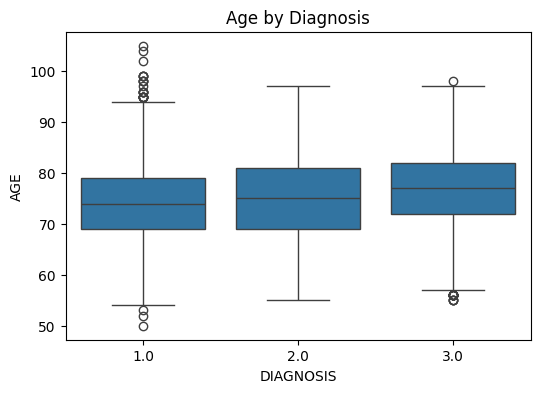

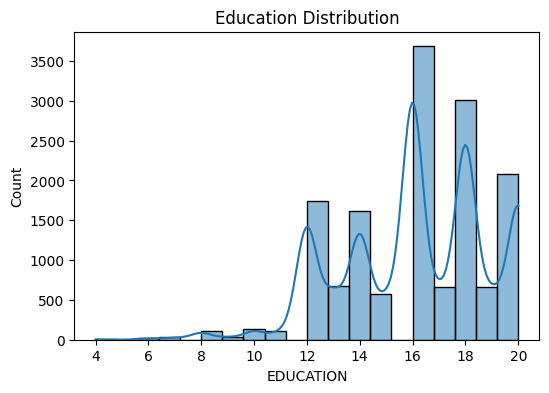

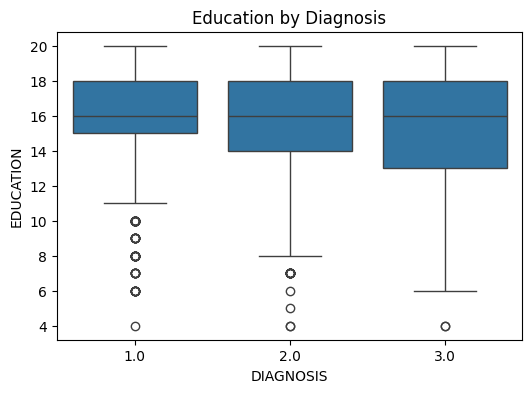

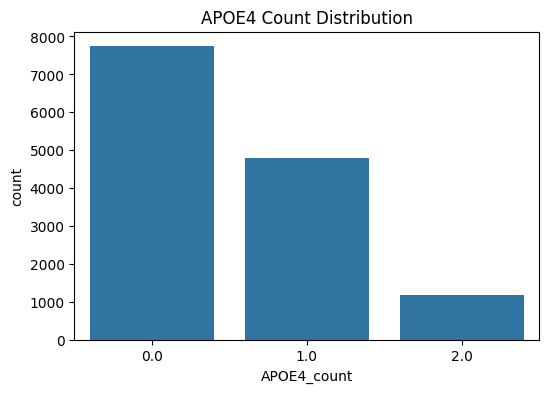

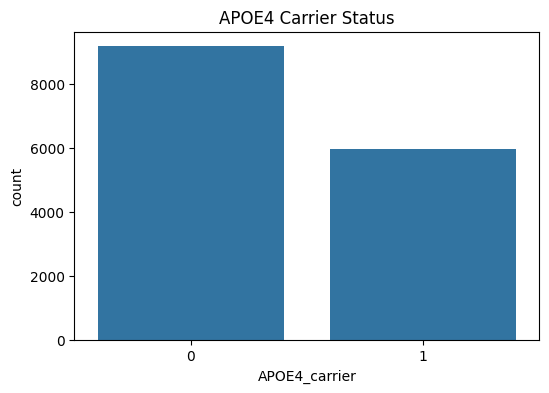

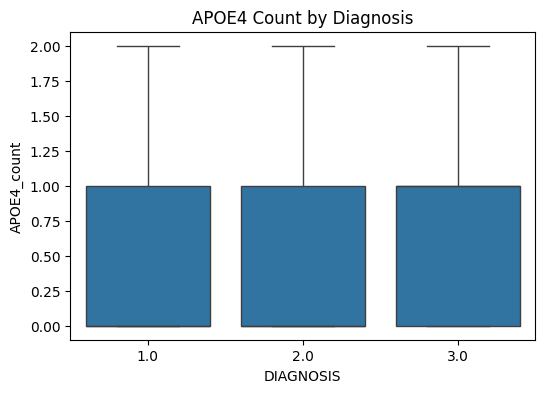

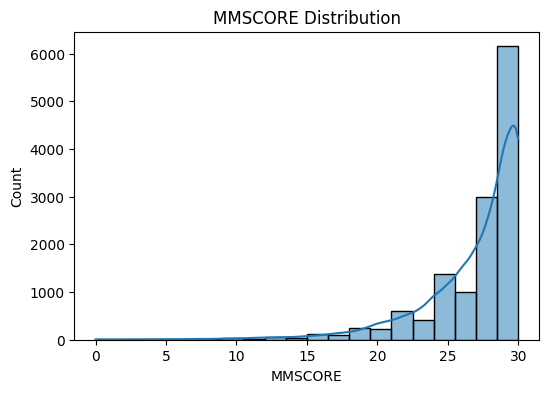

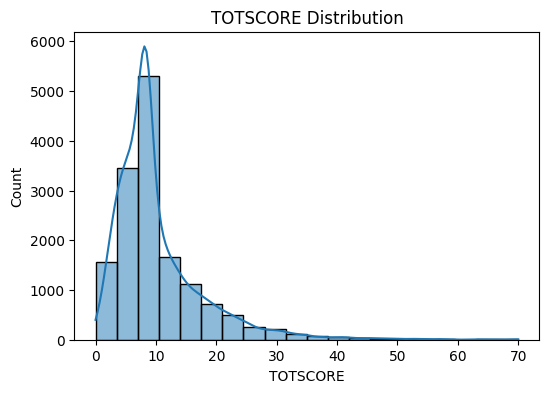

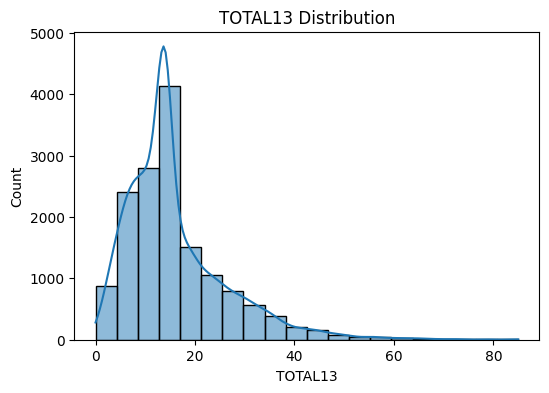

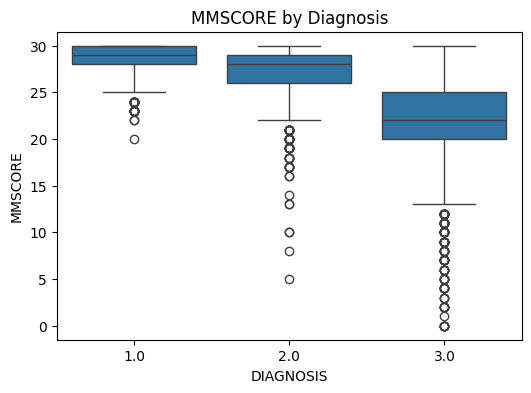

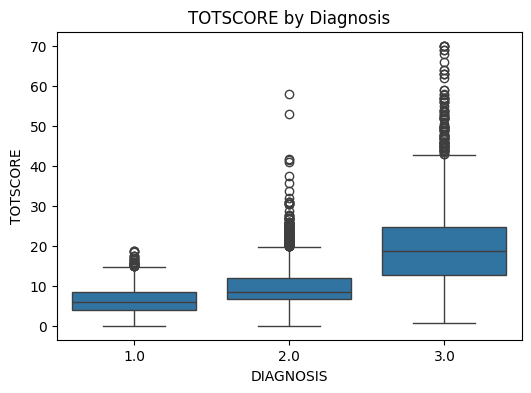

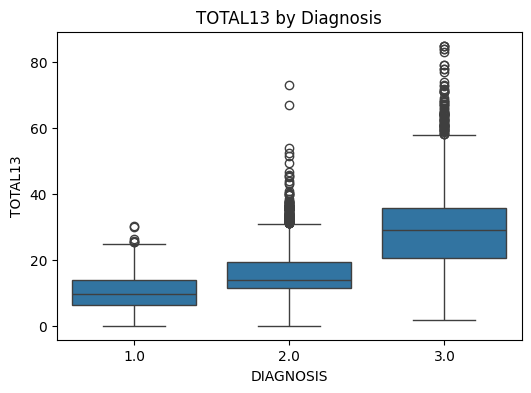

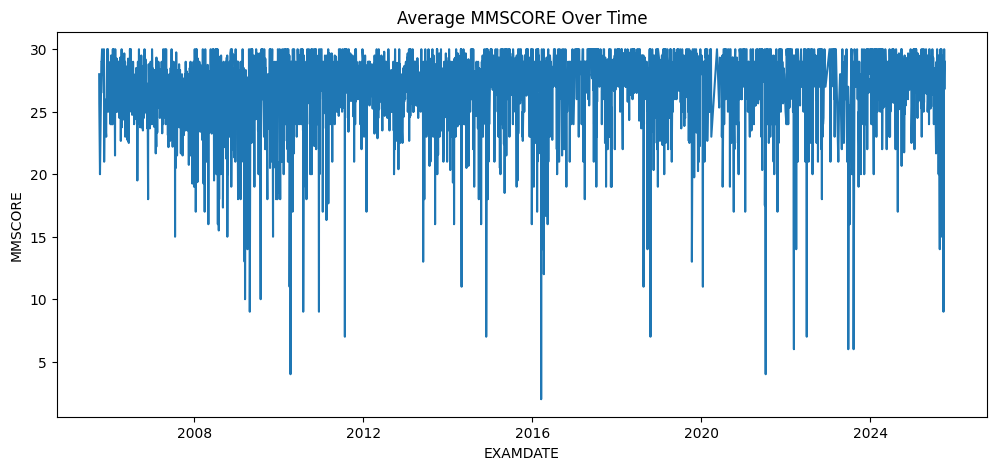

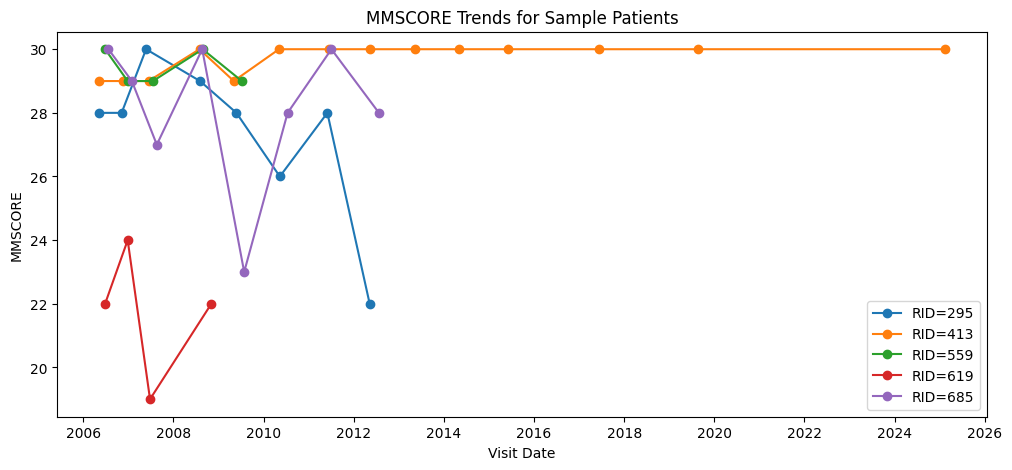

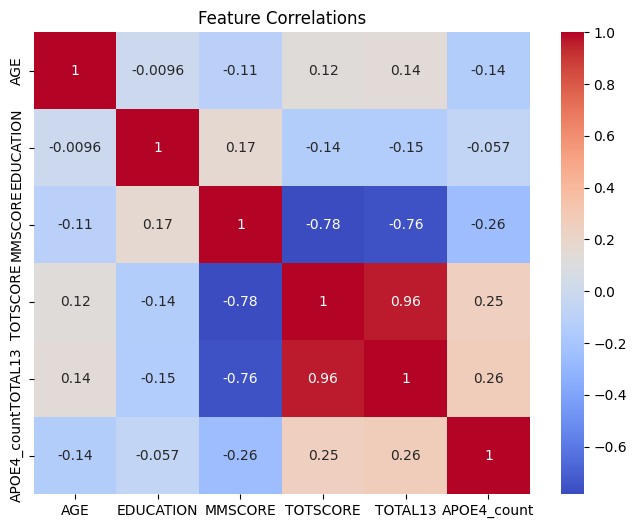

In [ ]:
# ==============================
# Alzheimer's Dataset EDA Script
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1️ Load dataset
df = pd.read_csv("FINAL_CLEAN_FULL_with_demo_apoe_age_fixed.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# -----------------------------
# 2️ Basic info
print("----- Dataset Info -----")
print(df.info())

print("\n----- Summary Statistics -----")
print(df.describe())

print("\n----- Missing Values -----")
print(df.isnull().sum())

# Drop 'SEX' column since all values are missing
if 'SEX' in df.columns:
    df = df.drop(columns=['SEX'])

# Drop rows with missing EXAMDATE
df = df.dropna(subset=['EXAMDATE'])
df['EXAMDATE'] = pd.to_datetime(df['EXAMDATE'])

# -----------------------------
# 3️ Diagnosis distribution
plt.figure(figsize=(6,4))
sns.countplot(x='DIAGNOSIS', data=df)
plt.title("Diagnosis Distribution (0=Normal,1=MCI,2=AD)")
plt.show()

# -----------------------------
# 4️ Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Age vs Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='AGE', data=df)
plt.title("Age by Diagnosis")
plt.show()

# -----------------------------
# 5️ Education distribution
plt.figure(figsize=(6,4))
sns.histplot(df['EDUCATION'], bins=20, kde=True)
plt.title("Education Distribution")
plt.show()

# Education vs Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='EDUCATION', data=df)
plt.title("Education by Diagnosis")
plt.show()

# -----------------------------
# 6️ APOE4 genetic info
plt.figure(figsize=(6,4))
sns.countplot(x='APOE4_count', data=df)
plt.title("APOE4 Count Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='APOE4_carrier', data=df)
plt.title("APOE4 Carrier Status")
plt.show()

# APOE4 vs Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='APOE4_count', data=df)
plt.title("APOE4 Count by Diagnosis")
plt.show()

# -----------------------------
# 7️ Cognitive Scores
# MMSCORE distribution
plt.figure(figsize=(6,4))
sns.histplot(df['MMSCORE'], bins=20, kde=True)
plt.title("MMSCORE Distribution")
plt.show()

# TOTSCORE distribution
plt.figure(figsize=(6,4))
sns.histplot(df['TOTSCORE'], bins=20, kde=True)
plt.title("TOTSCORE Distribution")
plt.show()

# TOTAL13 distribution
plt.figure(figsize=(6,4))
sns.histplot(df['TOTAL13'], bins=20, kde=True)
plt.title("TOTAL13 Distribution")
plt.show()

# Cognitive scores vs Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='MMSCORE', data=df)
plt.title("MMSCORE by Diagnosis")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='TOTSCORE', data=df)
plt.title("TOTSCORE by Diagnosis")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DIAGNOSIS', y='TOTAL13', data=df)
plt.title("TOTAL13 by Diagnosis")
plt.show()

# -----------------------------
# 8️ Cognitive decline trends over time
df_grouped = df.groupby('EXAMDATE')['MMSCORE'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(x='EXAMDATE', y='MMSCORE', data=df_grouped)
plt.title("Average MMSCORE Over Time")
plt.show()

# -----------------------------
# 9️ Sample patients cognitive trend
sample_patients = df['RID'].unique()[:5]  # first 5 patients
plt.figure(figsize=(12,5))
for pid in sample_patients:
    patient_data = df[df['RID'] == pid].sort_values('EXAMDATE')
    plt.plot(patient_data['EXAMDATE'], patient_data['MMSCORE'], marker='o', label=f'RID={pid}')
plt.xlabel("Visit Date")
plt.ylabel("MMSCORE")
plt.title("MMSCORE Trends for Sample Patients")
plt.legend()
plt.show()

# -----------------------------
# 10️ Feature correlations
plt.figure(figsize=(8,6))
corr = df[['AGE','EDUCATION','MMSCORE','TOTSCORE','TOTAL13','APOE4_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()


In [ ]:
from google.colab import files

# Replace with your file path
files.download("FINAL_CLEAN_FULL_with_demo_apoe_age_fixed.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>